Connected to the database.
Lade Daten aus der 'canvassamples'-Collection...
2004832 Dokumente aus 'canvassamples' geladen.
Lade Daten aus der 'fingerprints'-Collection...
21 Dokumente aus 'fingerprints' geladen.


Lade Bilder: 100%|██████████| 20001/20001 [00:12<00:00, 1607.97it/s]


Validation Set - F1 Score: 0.18233048536629703, Precision: 1.0, Recall: 0.1003100310031003, Accuracy: 0.1003100310031003
Test Set - F1 Score: 0.18617937789063208, Precision: 1.0, Recall: 0.10264486775661216, Accuracy: 0.10264486775661216


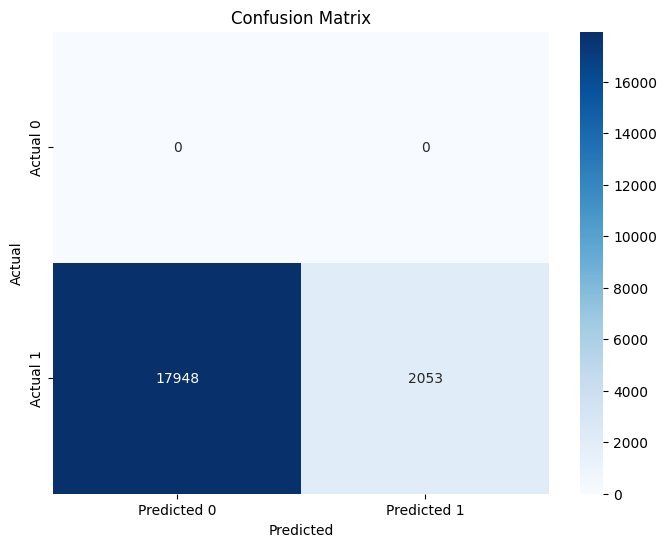

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


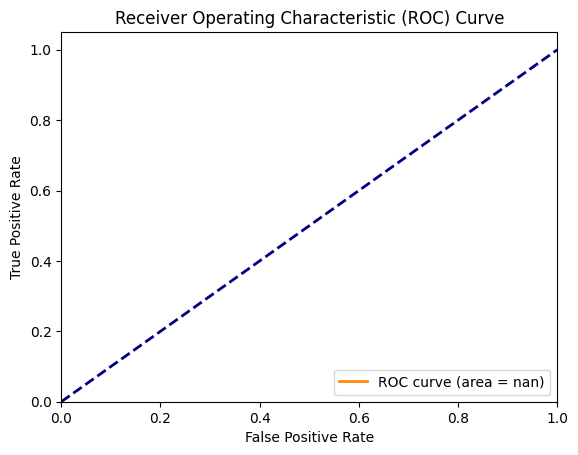

In [1]:
import os
import pandas as pd
import pymongo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from PIL import Image
import io
import numpy as np
from tqdm import tqdm
import gc

def connect_to_database():
    try:
        mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
        client = pymongo.MongoClient(mongo_uri)
        db = client.get_default_database()
        print("Connected to the database.")
        return db
    except pymongo.errors.ConnectionError as err:
        print(f"Error: {err}")
        return None

# Verbindung zur Datenbank herstellen
db = connect_to_database()
if db is None:
    print("Failed to connect to the database. Exiting...")
    exit()

# Daten aus der 'canvassamples'-Collection laden
print("Lade Daten aus der 'canvassamples'-Collection...")
canvassamples_collection = db['canvassamples']
canvassamples_cursor = canvassamples_collection.find()
canvassamples_data = list(canvassamples_cursor)
canvassamples_df = pd.DataFrame(canvassamples_data)
print(f"{len(canvassamples_data)} Dokumente aus 'canvassamples' geladen.")

# Daten aus der 'fingerprints'-Collection laden
print("Lade Daten aus der 'fingerprints'-Collection...")
fingerprints_collection = db['fingerprints']
fingerprints_cursor = fingerprints_collection.find()
fingerprints_data = list(fingerprints_cursor)
fingerprints_df = pd.DataFrame(fingerprints_data)
print(f"{len(fingerprints_data)} Dokumente aus 'fingerprints' geladen.")

# Funktion zum Aufteilen der Daten
def split_data(df):
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.6667, random_state=42)  # 0.6667 * 0.3 = 0.2
    return train_df, val_df, test_df

# Beispielhafte Benutzer-ID und zugehörige Daten
user_id = fingerprints_df.iloc[2]['_id']
username = fingerprints_df.iloc[2]['username']
user_samples = canvassamples_df[canvassamples_df['fingerprintId'] == user_id]
train_df, val_df, test_df = split_data(user_samples)

# Funktion zur Verarbeitung von Bildern in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image)  # No normalization
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

# Funktion zum Extrahieren von Bildern und Labels aus dem DataFrame
def extract_images_from_df(df, example_user_id):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['fingerprintId'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Bilddaten verarbeiten
try:
    X_train, y_train = extract_images_from_df(train_df, user_id)
    X_val, y_val = extract_images_from_df(val_df, user_id)
    X_test, y_test = extract_images_from_df(test_df, user_id)
except Exception as e:
    print(f"Fehler bei der Bilddatenverarbeitung: {e}")
    exit()

# Speicher freigeben
gc.collect()

# Überprüfen, ob die Bilddaten korrekt extrahiert wurden
if X_train.size == 0 or X_val.size == 0 or X_test.size == 0:
    print("Fehler: Bilddaten konnten nicht extrahiert werden.")
    exit()

# Isolation Forest trainieren
# Bilddaten für Isolation Forest flach machen
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Modell trainieren
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(X_train_flat)

# Vorhersagen für Validierungs- und Testsets
y_val_pred = model.predict(X_val_flat)
y_test_pred = model.predict(X_test_flat)

# Vorhersagen von {-1, 1} zu {0, 1} konvertieren
y_val_pred = np.where(y_val_pred == 1, 0, 1)
y_test_pred = np.where(y_test_pred == 1, 0, 1)

# Modell bewerten
# Validierungsset-Bewertung
f1_val = f1_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)

print(f"Validation Set - F1 Score: {f1_val}, Precision: {precision_val}, Recall: {recall_val}, Accuracy: {accuracy_val}")

# Testset-Bewertung
f1_test = f1_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"Test Set - F1 Score: {f1_test}, Precision: {precision_test}, Recall: {recall_test}, Accuracy: {accuracy_test}")

# Konfusionsmatrix
cm = confusion_matrix(y_test, y_test_pred)

# Konfusionsmatrix plotten
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC-Kurve und AUC
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [1]:
import os
import pandas as pd
import pymongo

def connect_to_database():
    try:
        mongo_uri = os.getenv('MONGO_URI', 'mongodb://db:27017/fingerprintDB')
        client = pymongo.MongoClient(mongo_uri)
        db = client.get_default_database()
        print("Connected to the database.")
        return db
    except pymongo.errors.ConnectionError as err:
        print(f"Error: {err}")
        return None

# Verbindung zur Datenbank herstellen
db = connect_to_database()
if db is None:
    print("Failed to connect to the database. Exiting...")
    exit()

# Daten aus der 'canvassamples'-Collection laden
print("Lade Daten aus der 'canvassamples'-Collection...")
canvassamples_collection = db['canvassamples']
canvassamples_cursor = canvassamples_collection.find()
canvassamples_data = list(canvassamples_cursor)
canvassamples_df = pd.DataFrame(canvassamples_data)
print(f"{len(canvassamples_data)} Dokumente aus 'canvassamples' geladen.")

# Daten aus der 'fingerprints'-Collection laden
print("Lade Daten aus der 'fingerprints'-Collection...")
fingerprints_collection = db['fingerprints']
fingerprints_cursor = fingerprints_collection.find()
fingerprints_data = list(fingerprints_cursor)
fingerprints_df = pd.DataFrame(fingerprints_data)
print(f"{len(fingerprints_data)} Dokumente aus 'fingerprints' geladen.")

Connected to the database.
Lade Daten aus der 'canvassamples'-Collection...
2004832 Dokumente aus 'canvassamples' geladen.
Lade Daten aus der 'fingerprints'-Collection...
21 Dokumente aus 'fingerprints' geladen.


In [2]:
print(canvassamples_df.head())
print(fingerprints_df.head())

                        _id             fingerprintId  \
0  66e326e9fab6918841db55db  66e326e8fab6918841db55d1   
1  66e326e9fab6918841db55df  66e326e8fab6918841db55d1   
2  66e326e9fab6918841db55d6  66e326e8fab6918841db55d1   
3  66e326e9fab6918841db55e3  66e326e8fab6918841db55d1   
4  66e326eafab6918841db55e7  66e326e8fab6918841db55d1   

                                          sampleData               createdAt  \
0  iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA... 2024-09-12 17:37:45.847   
1  iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA... 2024-09-12 17:37:45.906   
2  iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA... 2024-09-12 17:37:45.772   
3  iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA... 2024-09-12 17:37:45.981   
4  iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA... 2024-09-12 17:37:46.049   

   __v  
0    0  
1    0  
2    0  
3    0  
4    0  
                        _id  \
0  66e326e8fab6918841db55d1   
1  6703f8339717b7a0d179d6df   
2  6704027b9717b7a0d17f219a  

In [3]:
# Datenaufteilung
def split_data(df):
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.6667, random_state=42)  # 0.6667 * 0.3 = 0.2
    return train_df, val_df, test_df

# Beispiel für die Aufteilung der Daten eines Benutzers
user_id = fingerprints_df.iloc[2]['_id']  # Benutzer 3
username = fingerprints_df.iloc[2]['username']
user_samples = canvassamples_df[canvassamples_df['fingerprintId'] == user_id]
train_df, val_df, test_df = split_data(user_samples)

NameError: name 'train_test_split' is not defined

In [ ]:
# Merkmalsextraktion
def extract_features(df):
    stats_df = pd.DataFrame(df['statistics'].tolist())
    hist_df = pd.DataFrame(df['histogram'].tolist())
    
    X = pd.concat([stats_df, hist_df], axis=1)
    X.columns = X.columns.astype(str)
    
    return X

# Merkmale extrahieren
train_features = extract_features(prepare_data(train_df))
val_features = extract_features(prepare_data(val_df))
test_features = extract_features(prepare_data(test_df))

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib

# Isolation Forest Modell trainieren
def train_isolation_forest(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = IsolationForest(contamination=0.1)
    model.fit(X_scaled)
    
    return model, scaler

# Modell trainieren und speichern
def train_and_save_model(X, username):
    isolation_forest_model, scaler = train_isolation_forest(X)
    
    os.makedirs('Modelle/IsolationForest2', exist_ok=True)
    joblib.dump(isolation_forest_model, f'Modelle/IsolationForest2/{username}_model.pkl')
    joblib.dump(scaler, f'Modelle/IsolationForest2/{username}_scaler.pkl')
    print(f"Modell und Scaler für {username} gespeichert.")
    
    return isolation_forest_model, scaler

# Modell für den Benutzer trainieren und speichern
isolation_forest_model, scaler = train_and_save_model(train_features, username)

In [ ]:
# Verzeichnis für Modelle erstellen
model_dir = "Modelle/Isolation_Forest"
os.makedirs(model_dir, exist_ok=True)

# Modell erstellen
isolation_forest = IsolationForest(contamination=0.1, random_state=42)

# Modell trainieren
isolation_forest.fit(X_train)

# Modell speichern
model_path = os.path.join(model_dir, "isolation_forest_model.pkl")
joblib.dump(isolation_forest, model_path)
print(f"Modell gespeichert unter: {model_path}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Vorhersagen treffen
def make_predictions(X, model, scaler):
    X_scaled = scaler.transform(X)
    preds = model.predict(X_scaled)
    
    preds = np.where(preds == -1, 0, 1)
    return preds

# Grafische Darstellung der Ergebnisse
def plot_results(preds, title):
    plt.figure(figsize=(10, 6))
    sns.countplot(x=preds)
    plt.title(title)
    plt.xlabel('Anomaly')
    plt.ylabel('Count')
    plt.show()

# Modell gegen 10 Samples von Benutzer 3 testen
user_samples_test = test_df.sample(10, random_state=42)
test_features_user = extract_features(prepare_data(user_samples_test))
predictions_user = make_predictions(test_features_user, isolation_forest_model, scaler)
plot_results(predictions_user, f'Anomalien in 10 Samples von {username}')

# Modell gegen 5 zufällige Samples von anderen Benutzern testen
other_users_samples = canvassamples_df[canvassamples_df['fingerprintId'] != user_id].sample(5, random_state=42)
test_features_other = extract_features(prepare_data(other_users_samples))
predictions_other = make_predictions(test_features_other, isolation_forest_model, scaler)
plot_results(predictions_other, f'Anomalien in 5 zufälligen Samples von anderen Benutzern')

In [ ]:
# Ergebnisse erklären
def explain_results(preds, title):
    total_samples = len(preds)
    anomalies = np.sum(preds == 0)
    normal = total_samples - anomalies
    
    print(f"{title}")
    print(f"Gesamtanzahl der Samples: {total_samples}")
    print(f"Anzahl der Anomalien: {anomalies}")
    print(f"Anzahl der normalen Samples: {normal}")
    print("\n")

# Ergebnisse für Benutzer 3 erklären
explain_results(predictions_user, f'Ergebnisse für 10 Samples von {username}')

# Ergebnisse für andere Benutzer erklären
explain_results(predictions_other, 'Ergebnisse für 5 zufällige Samples von anderen Benutzern')

In [ ]:
# Modell gegen 5 verschiedene Benutzer mit je 10 Samples testen
def test_model_against_multiple_users(model, scaler, num_users=5, samples_per_user=10):
    other_users = fingerprints_df[fingerprints_df['_id'] != user_id].sample(num_users, random_state=42)
    for _, user in other_users.iterrows():
        other_user_id = user['_id']
        other_username = user['username']
        other_user_samples = canvassamples_df[canvassamples_df['fingerprintId'] == other_user_id].sample(samples_per_user, random_state=42)
        test_features_other_user = extract_features(prepare_data(other_user_samples))
        predictions_other_user = make_predictions(test_features_other_user, model, scaler)
        plot_results(predictions_other_user, f'Anomalien in 10 Samples von {other_username}')
        explain_results(predictions_other_user, f'Ergebnisse für 10 Samples von {other_username}')

# Testen des Modells gegen 5 verschiedene Benutzer mit je 10 Samples
test_model_against_multiple_users(isolation_forest_model, scaler, num_users=5, samples_per_user=10)